In [204]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes


db = load_diabetes()
df = pd.DataFrame(db.data,columns= db.feature_names)
df['Disease Progression'] = db.target
df

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,Disease Progression
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
...,...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207,178.0
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485,104.0
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491,132.0
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930,220.0


In [205]:
X,Y = load_diabetes(return_X_y= True)

In [206]:
X.shape

(442, 10)

In [207]:
Y.shape

(442,)

# Using ScikitLearn's Regression

In [208]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=2)
from sklearn.linear_model import LinearRegression
reg = LinearRegression()

In [209]:
reg.fit(X_train,Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [210]:
y_pred = reg.predict(X_test)

In [211]:
from sklearn.metrics import r2_score

In [212]:
r2_score(Y_test,y_pred)

0.439933866156897

In [213]:
reg.coef_

array([  -9.15865318, -205.45432163,  516.69374454,  340.61999905,
       -895.5520019 ,  561.22067904,  153.89310954,  126.73139688,
        861.12700152,   52.42112238])

In [214]:
reg.intercept_

np.float64(151.88331005254167)

In [215]:
X_test

array([[ 0.06713621, -0.04464164,  0.00349435,  0.03564379,  0.0493413 ,
         0.03125356,  0.07072993, -0.03949338, -0.00061174,  0.01963284],
       [-0.07816532,  0.05068012,  0.07786339,  0.05285804,  0.07823631,
         0.0644473 ,  0.02655027, -0.00259226,  0.04067283, -0.00936191],
       [ 0.04170844,  0.05068012, -0.01482845, -0.01713512, -0.00569682,
         0.00839372, -0.01394774, -0.00185424, -0.01189685,  0.00306441],
       [-0.04547248, -0.04464164, -0.04824063, -0.01944183, -0.00019301,
        -0.01603186,  0.06704829, -0.03949338, -0.02479543,  0.01963284],
       [ 0.0090156 ,  0.05068012,  0.06924089,  0.05974375,  0.01769438,
        -0.02323427, -0.04708248,  0.03430886,  0.10329702,  0.07348023],
       [ 0.03444337,  0.05068012,  0.12528712,  0.02875809, -0.05385517,
        -0.01290037, -0.10230705,  0.1081111 ,  0.00027248,  0.02791705],
       [-0.03457486, -0.04464164, -0.05901875,  0.00121528, -0.05385517,
        -0.07803525,  0.06704829, -0.0763945 

# Making our own Linear Regression

In [216]:
class mLR:
    def __init__(self):
        self.coef = None
        self.intercept = None
    def fit(self,X_train,Y_train):
        X_train = np.insert(X_train,0,1,axis=1)

        betas = np.linalg.inv(np.dot(X_train.T,X_train)).dot(X_train.T).dot(Y_train)
        print(np.linalg.inv(np.dot(X_train.T,X_train)).dot(np.dot(X_train.T,Y_train)))
        
        self.intercept = betas[0]
        self.coef = betas[1:]

    def predict(self, X_test):
        return np.dot(X_test,self.coef) + self.intercept 
        print("predict")

In [217]:
LR = mLR()
LR.fit(X_train,Y_train)

[ 151.88331005   -9.15865318 -205.45432163  516.69374454  340.61999905
 -895.5520019   561.22067904  153.89310954  126.73139688  861.12700152
   52.42112238]


In [218]:
LR.predict(X_test)

array([154.1213881 , 204.81835118, 124.93755353, 106.08950893,
       258.5348576 , 256.3310074 , 118.75087616, 119.52440696,
       101.50816735, 190.54048661, 141.70656811, 172.51883961,
       174.33861649, 134.80942706, 294.13994537,  94.11798038,
       211.97059795, 156.49579378, 134.21000428, 119.62664644,
       148.87842251, 165.00873409, 151.10021038, 176.04063756,
       133.27769647, 221.29555392, 197.17324941,  96.1577688 ,
        50.26012711, 230.48580317, 242.06073866, 114.11129218,
        67.07532417,  94.52943825, 201.21415375, 167.05136201,
       159.881268  , 192.78746659, 114.49551325, 233.48234551,
       140.82563045, 121.0680409 , 192.27480772, 191.12738845,
       179.16865788, 148.34935601, 163.47414622, 276.81647884,
       100.17926432, 164.10555298, 255.80762189, 136.9466204 ,
       152.37503699, 107.92237882, 194.21924678,  77.34670792,
       118.50482479,  68.38335763, 154.29258529, 162.48840259,
       168.36788326, 156.87790322,  97.14191797, 238.16

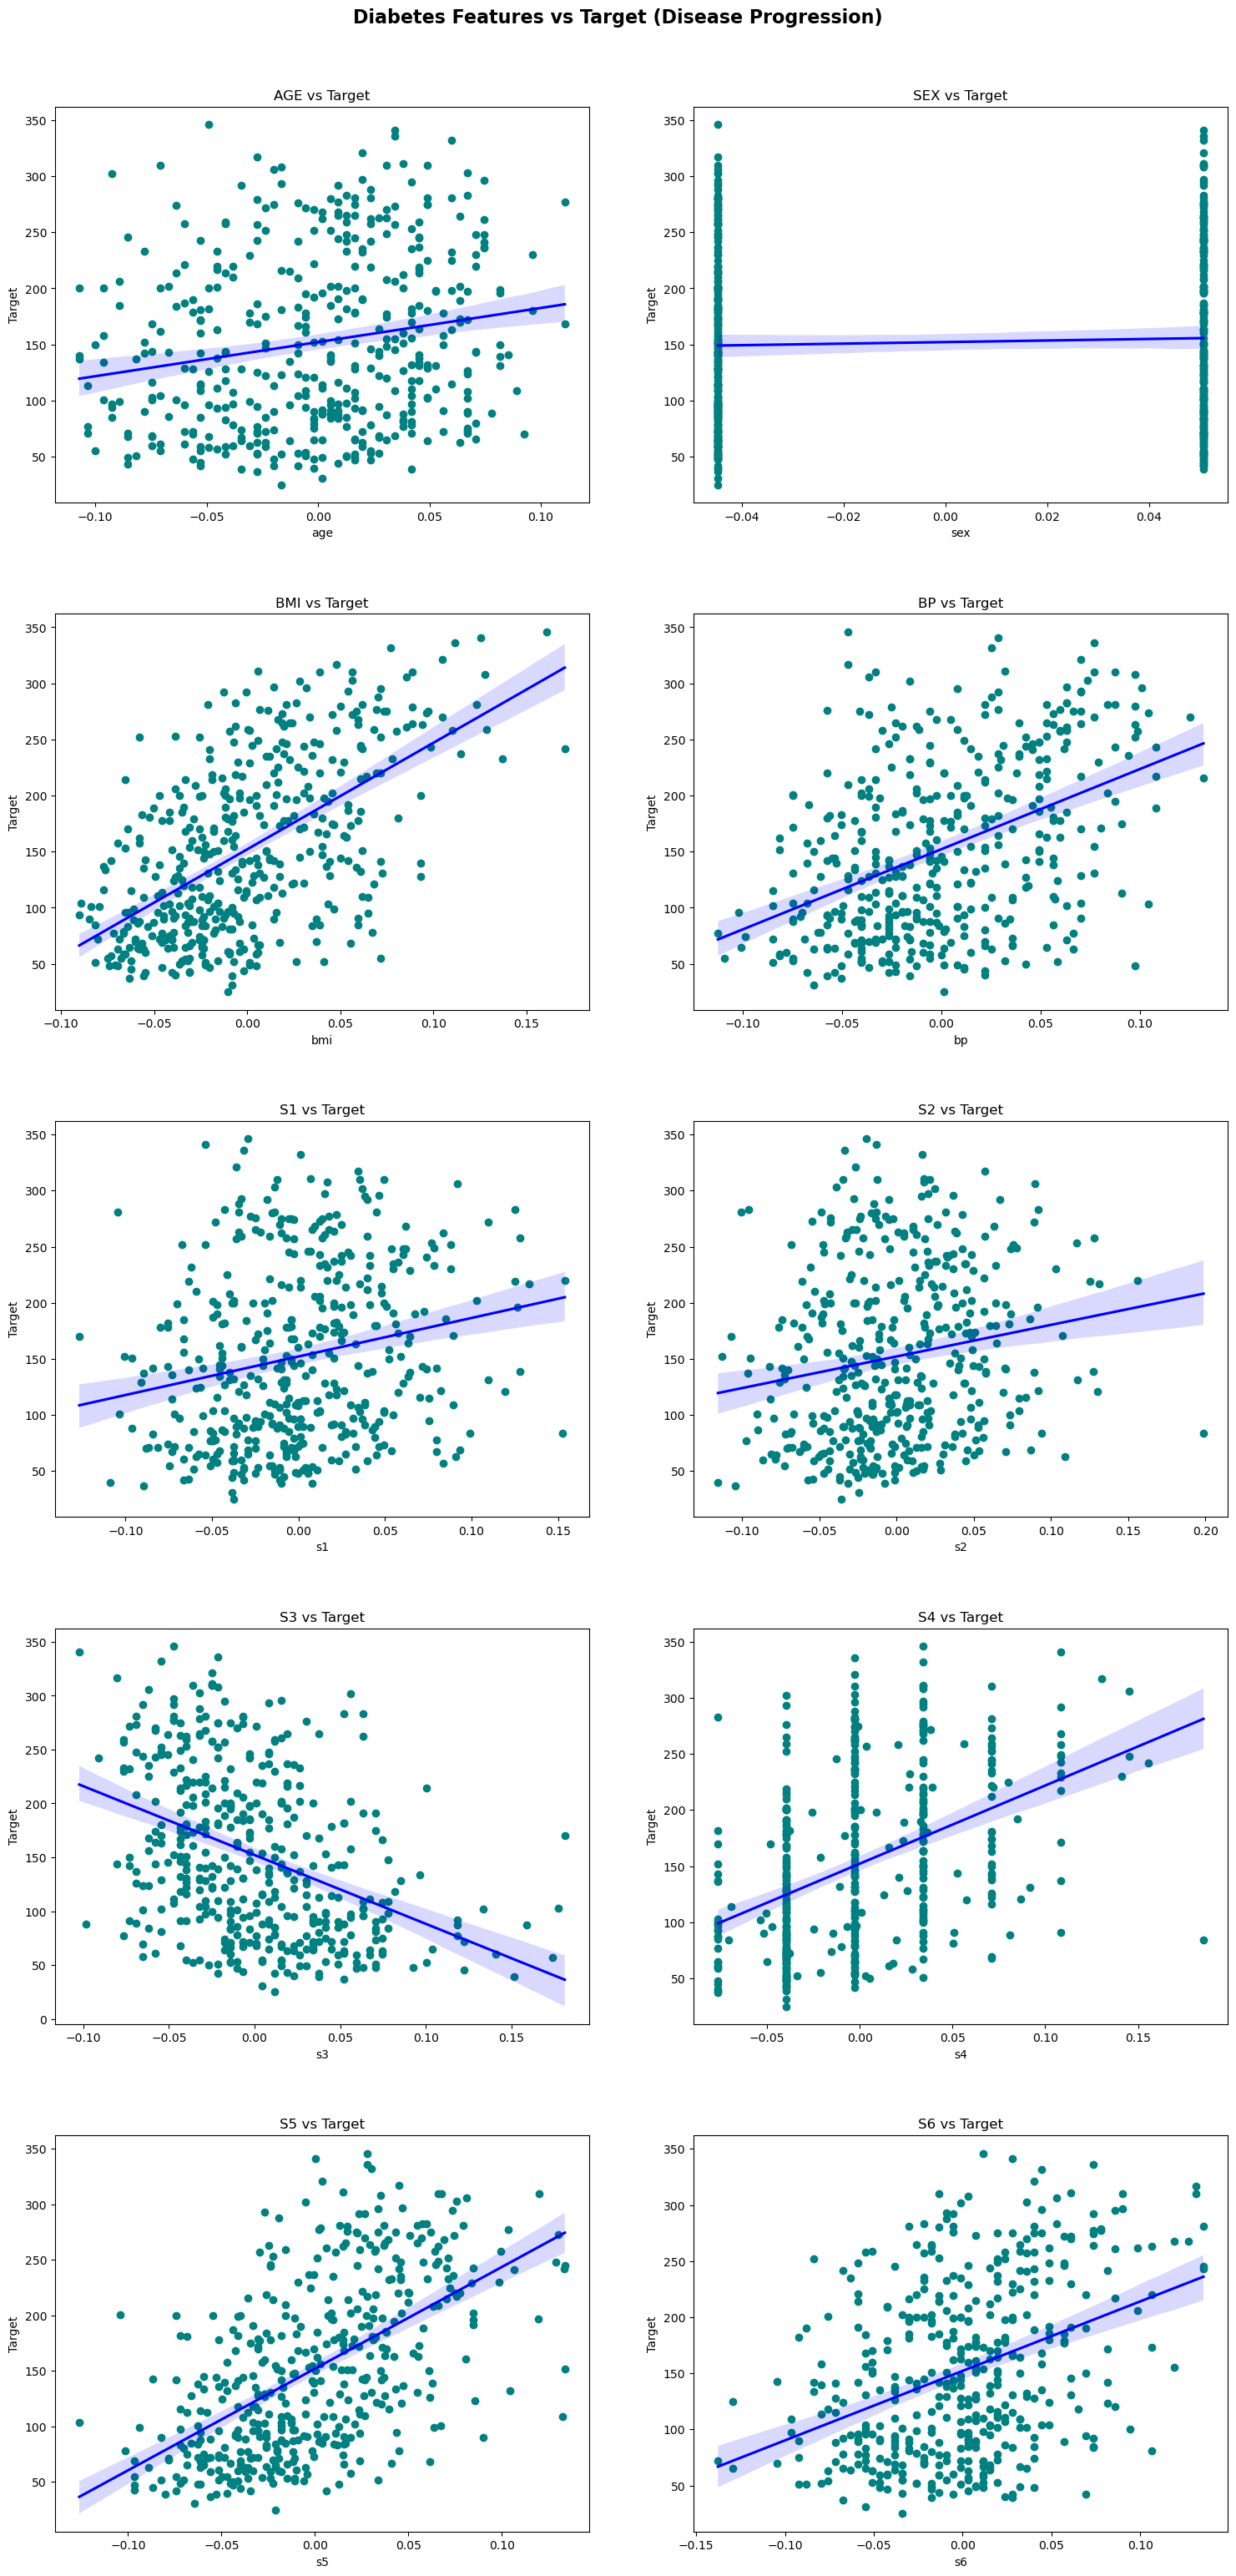

In [228]:
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(16, 32))
fig.suptitle('Diabetes Features vs Target (Disease Progression)', fontsize=16, fontweight='bold')


for i, col in enumerate(db.feature_names):
    row = i // 2
    column = i % 2
    ax = axes[row, column]
    

    sns.regplot(data=df, x=col, y='target', ax=ax, 
                scatter_kws={'alpha':1, 'color':'teal'}, 
                line_kws={'color':'blue'})
    
    ax.set_title(f'{col.upper()} vs Target')
    ax.set_xlabel(col)
    ax.set_ylabel('Target')


plt.tight_layout(pad=5)
plt.show()
